In [178]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [179]:
# Read the JSON file
with open('results/ablation_results.json', 'r') as f:
    ablation_data = json.load(f)

In [180]:
ablation_data

{'1': {'0': {'cora': {'faf_true': {'acc': 0.6350000500679016,
     'time': 0.4170694351196289,
     'params': 459079},
    'faf_rand': {'acc': 0.1860000044107437,
     'time': 0.2805051803588867,
     'params': 459079}},
   'pubmed': {'faf_true': {'acc': 0.6850000619888306,
     'time': 0.4422447681427002,
     'params': 160259},
    'faf_rand': {'acc': 0.5060000419616699,
     'time': 0.46443819999694824,
     'params': 160259}},
   'amazon': {'faf_true': {'acc': 0.7930000424385071,
     'time': 0.3367183208465576,
     'params': 238984},
    'faf_rand': {'acc': 0.5720000267028809,
     'time': 0.3408384323120117,
     'params': 238984}}},
  '1': {'cora': {'faf_true': {'acc': 0.5180000066757202,
     'time': 0.28725194931030273,
     'params': 459079},
    'faf_rand': {'acc': 0.18900001049041748,
     'time': 0.29993772506713867,
     'params': 459079}},
   'pubmed': {'faf_true': {'acc': 0.6430000066757202,
     'time': 0.4717748165130615,
     'params': 160259},
    'faf_rand': {'acc

In [181]:
# Calculate mean accuracy and standard deviation for each value of K and model
mean_accuracies = {}

for k, seeds in ablation_data.items():
    mean_accuracies[k] = {
        'cora': {
            'faf_true': 0,
            'faf_rand': 0,
        },
        'pubmed': {
            'faf_true': 0,
            'faf_rand': 0,
        },
        'amazon': {
            'faf_true': 0,
            'faf_rand': 0,
        },
    }
    for seed, datasets in seeds.items():
        for dataset, models in datasets.items():
            for model, stats in models.items():
                mean_accuracies[k][dataset][model] += stats['acc']

    for dataset, models in mean_accuracies[k].items():
        for model in models:
            mean_accuracies[k][dataset][model] /= len(seeds)

In [182]:
std_accuracies = {}

for k, seeds in ablation_data.items():
    std_accuracies[k] = {
        'cora': {
            'faf_true': 0,
            'faf_rand': 0,
        },
        'pubmed': {
            'faf_true': 0,
            'faf_rand': 0,
        },
        'amazon': {
            'faf_true': 0,
            'faf_rand': 0,
        },
    }
    for seed, datasets in seeds.items():
        for dataset, models in datasets.items():
            for model, stats in models.items():
                std_accuracies[k][dataset][model] += (stats['acc'] - mean_accuracies[k][dataset][model]) ** 2

    for dataset, models in std_accuracies[k].items():
        for model in models:
            std_accuracies[k][dataset][model] = (std_accuracies[k][dataset][model] / len(seeds)) ** 0.5

In [183]:
idx_to_name = {
    'cora': 'Cora',
    'pubmed': 'PubMed',
    'amazon': 'Amazon Photo'
}

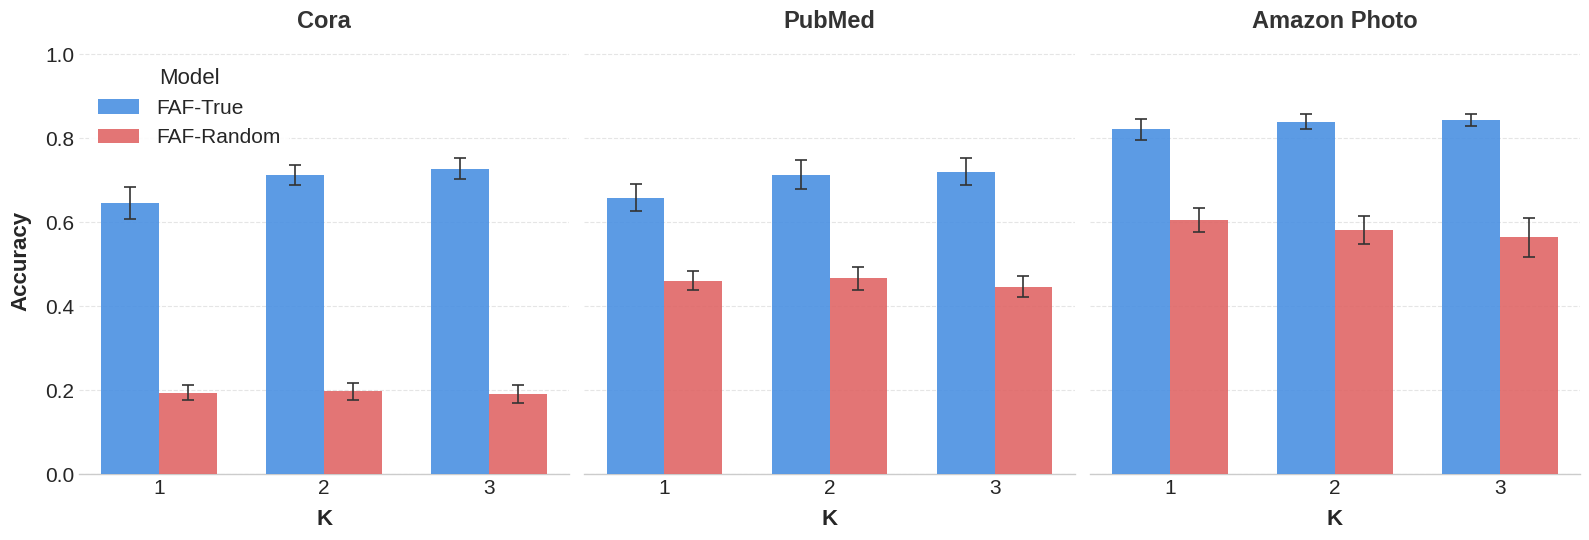

In [184]:
# Bar plot for accuracy for each value of K and model
# Include standard deviation as error bars
# 1. Set a clean, professional base style
plt.style.use('seaborn-v0_8-whitegrid') # Uses a clean grid layout
plt.rcParams['font.family'] = 'sans-serif'

# 2. Define a modern, cohesive color palette
COLOR_TRUE = '#4A90E2'  # Sleek Slate Blue
COLOR_RAND = '#E06666'  # Soft Coral

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)

# Map dataset keys to clean display names if idx_to_name isn't handling capitalization
for ax, dataset in zip(axes, ['cora', 'pubmed', 'amazon']):
    x = list(mean_accuracies.keys())
    y_faf_true = [mean_accuracies[k][dataset]['faf_true'] for k in x]
    y_faf_rand = [mean_accuracies[k][dataset]['faf_rand'] for k in x]
    yerr_faf_true = [std_accuracies[k][dataset]['faf_true'] for k in x]
    yerr_faf_rand = [std_accuracies[k][dataset]['faf_rand'] for k in x]

    # Subtle background grid (horizontal only)
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.grid(False, axis='x') # Remove vertical grid lines for cleaner look

    # Plot bars with custom width, spacing, and styling
    width = 0.35
    x_indices = range(len(x))
    
    # FAF True
    ax.bar([i - width/2 for i in x_indices], y_faf_true, width=width, 
           label='FAF-True', color=COLOR_TRUE, alpha=0.9,
           yerr=yerr_faf_true, capsize=4, 
           error_kw={'ecolor': '#333333', 'elinewidth': 1.2, 'capthick': 1.2},
           zorder=3) # zorder ensures bars sit on top of gridlines
    
    # FAF Rand
    ax.bar([i + width/2 for i in x_indices], y_faf_rand, width=width, 
           label='FAF-Random', color=COLOR_RAND, alpha=0.9,
           yerr=yerr_faf_rand, capsize=4, 
           error_kw={'ecolor': '#333333', 'elinewidth': 1.2, 'capthick': 1.2},
           zorder=3)

    # Clean up axes & labels
    ax.set_xticks(x_indices)
    ax.set_xticklabels(x, fontsize=15)
    ax.set_xlabel('K', fontsize=16, labelpad=8, fontweight='semibold')
    
    # Title styling
    title_name = idx_to_name.get(dataset, dataset)
    ax.set_title(title_name, fontsize=17, pad=15, fontweight='bold', color='#333333')
    
    # Remove unnecessary border spines
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
        
    # Legend tweak (clean and subtle frame)
    # ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)

# Y-Axis adjustments (Only apply labels to the first plot for a cleaner look)
axes[0].set_ylabel('Accuracy', fontsize=16, labelpad=10, fontweight='semibold')
axes[0].tick_params(axis='y', labelsize=15)

# Ensure the y-axis has a bit of breathing room at the top for the legend
plt.ylim(0, max(max(y_faf_true), max(y_faf_rand)) * 1.2)

axes[0].legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none', framealpha=0.9, fontsize=15, title='Model', title_fontsize=16)
plt.tight_layout()
plt.savefig("figures/k_ablation.png", dpi=300, bbox_inches="tight")
plt.show()

In [185]:
# Read the JSON file
with open('results/final_results.json', 'r') as f:
    final_data = json.load(f)

In [186]:
final_data

{'0': {'cora': {'mlp_x': {'acc': 0.5700000524520874,
    'time': 0.2162036895751953,
    'params': 92231},
   'faf_true': {'acc': 0.718000054359436,
    'time': 0.38185834884643555,
    'params': 825927},
   'faf_rand': {'acc': 0.17900000512599945,
    'time': 0.38654327392578125,
    'params': 825927},
   'gcn': {'acc': 0.7930000424385071,
    'time': 0.5140736103057861,
    'params': 92231},
   'deltas': {'graph': 0.14800000190734863,
    'structure': 0.5390000492334366,
    'random_vs_x': -0.39100004732608795,
    'learned': 0.07499998807907104}},
  'pubmed': {'mlp_x': {'acc': 0.7280000448226929,
    'time': 0.2549781799316406,
    'params': 32259},
   'faf_true': {'acc': 0.7430000305175781,
    'time': 0.6558923721313477,
    'params': 288259},
   'faf_rand': {'acc': 0.4660000205039978,
    'time': 0.6666140556335449,
    'params': 288259},
   'gcn': {'acc': 0.7820000648498535,
    'time': 0.5611252784729004,
    'params': 32259},
   'deltas': {'graph': 0.014999985694885254,
    's

In [187]:
final_data['0']['cora']['mlp_x']['acc']

0.5700000524520874

In [188]:
mean_accuracies = {}

for dataset in ['cora', 'pubmed', 'amazon']:
    mean_accuracies[dataset] = {
        'mlp_x': 0,
        'faf_true': 0,
        'faf_rand': 0,
        'gcn': 0,
    }

for seed, datasets in final_data.items():
    for dataset, models in datasets.items():
        for model, stats in models.items():
            if model == 'deltas':
                continue
            mean_accuracies[dataset][model] += stats['acc']

for dataset, models in mean_accuracies.items():
    for model in models:
        mean_accuracies[dataset][model] /= len(final_data)

In [189]:
std_accuracies = {}

for dataset in ['cora', 'pubmed', 'amazon']:
    std_accuracies[dataset] = {
        'mlp_x': 0,
        'faf_true': 0,
        'faf_rand': 0,
        'gcn': 0,
    }

for seed, datasets in final_data.items():
    for dataset, models in datasets.items():
        for model, stats in models.items():
            if model == 'deltas':
                continue
            std_accuracies[dataset][model] += (stats['acc'] - mean_accuracies[dataset][model]) ** 2

for dataset, models in std_accuracies.items():
    for model in models:
        std_accuracies[dataset][model] = (std_accuracies[dataset][model] / len(final_data)) ** 0.5

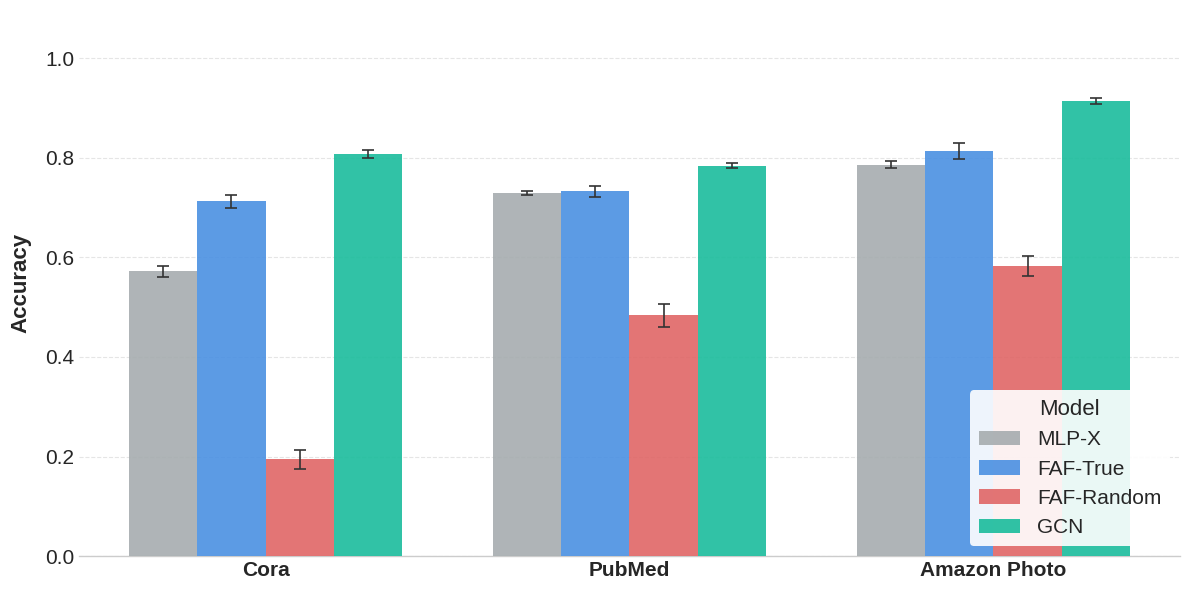

In [190]:
# 1. Set a clean, professional base style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

# 2. Define the consistent color palette & legend labels
COLOR_TRUE = '#4A90E2'   # Sleek Slate Blue
COLOR_RAND = '#E06666'   # Soft Coral
EXTRA_COLORS = ['#A6ACAF', '#1ABC9C', '#748896', '#F39C12'] # Fallback for other models

COLOR_MAP = {
    'faf_true': COLOR_TRUE,
    'faf_rand': COLOR_RAND
}

LABEL_MAP = {
    'mlp_x': 'MLP-X',
    'faf_true': 'FAF-True',
    'faf_rand': 'FAF-Random',
    'gcn': 'GCN',
}

# 3. Gather datasets and identify all unique models across them dynamically
datasets = ['cora', 'pubmed', 'amazon']
all_models = []
for dataset in datasets:
    for model in mean_accuracies[dataset].keys():
        if model not in all_models:
            all_models.append(model)

# Assign colors dynamically for any extra model types not explicitly mapped
extra_idx = 0
for model in all_models:
    if model not in COLOR_MAP:
        COLOR_MAP[model] = EXTRA_COLORS[extra_idx % len(EXTRA_COLORS)]
        extra_idx += 1

# 4. Set up the single figure and layout dimensions
fig, ax = plt.subplots(figsize=(12, 6))

num_datasets = len(datasets)
num_models = len(all_models)
total_group_width = 0.75  # Total width fraction allocated for each dataset's cluster of bars
bar_width = total_group_width / num_models
x_indices = np.arange(num_datasets)

# Subtle background grid (horizontal lines only)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.grid(False, axis='x') 

# 5. Plot grouped bars model by model across all datasets
for i, model in enumerate(all_models):
    # Fallback to 0 if a specific model doesn't exist in a dataset
    y = [mean_accuracies[dataset].get(model, 0) for dataset in datasets]
    yerr = [std_accuracies[dataset].get(model, 0) for dataset in datasets]
    
    # Calculate perfectly centered offsets for each bar within its dataset cluster
    offset = (i - (num_models - 1) / 2) * bar_width
    positions = x_indices + offset
    
    ax.bar(positions, y, width=bar_width, 
           label=LABEL_MAP.get(model, model.replace('_', ' ').title()), 
           color=COLOR_MAP[model], alpha=0.9,
           yerr=yerr, capsize=4, 
           error_kw={'ecolor': '#333333', 'elinewidth': 1.2, 'capthick': 1.2},
           zorder=3)

# 6. Clean up axes, titles, & labels
ax.set_xticks(x_indices)
display_names = [idx_to_name.get(ds, ds) for ds in datasets]
ax.set_xticklabels(display_names, fontsize=15, fontweight='semibold')
# ax.set_xlabel('Dataset', fontsize=13, labelpad=10, fontweight='semibold')

ax.set_ylabel('Accuracy', fontsize=16, labelpad=10, fontweight='semibold')
ax.tick_params(axis='y', labelsize=15)

# Title styling
# ax.set_title('Model Performance Comparison Across Datasets', fontsize=15, pad=20, fontweight='bold', color='#333333')

# Remove unnecessary border spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Clean, floating legend panel
ax.legend(title='Model', title_fontsize=16, loc='lower right', frameon=True, facecolor='white', edgecolor='none', framealpha=0.9, fontsize=15)

# Dynamically give the highest bar a bit of top breathing room for the legend
all_y_values = [val for dataset_dict in mean_accuracies.values() for val in dataset_dict.values()]
if all_y_values:
    ax.set_ylim(0, max(all_y_values) * 1.2)

plt.tight_layout()
plt.savefig("figures/accuracy_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [191]:
mean_deltas = {}

for dataset in ['cora', 'pubmed', 'amazon']:
    mean_deltas[dataset] = {
        'graph': 0,
        'structure': 0,
        'random_vs_x': 0,
        'learned': 0,
    }

for seed, datasets in final_data.items():
    for dataset, models in datasets.items():
        for type, value in models['deltas'].items():
            mean_deltas[dataset][type] += value

for dataset, types in mean_deltas.items():
    for type in types:
        mean_deltas[dataset][type] /= len(final_data)

In [192]:
std_deltas = {}

for dataset in ['cora', 'pubmed', 'amazon']:
    std_deltas[dataset] = {
        'graph': 0,
        'structure': 0,
        'random_vs_x': 0,
        'learned': 0,
    }

for seed, datasets in final_data.items():
    for dataset, models in datasets.items():
        for type, value in models['deltas'].items():
            std_deltas[dataset][type] += (value - mean_deltas[dataset][type]) ** 2

for dataset, types in std_deltas.items():
    for type in types:
        std_deltas[dataset][type] = (std_deltas[dataset][type] / len(final_data)) ** 0.5

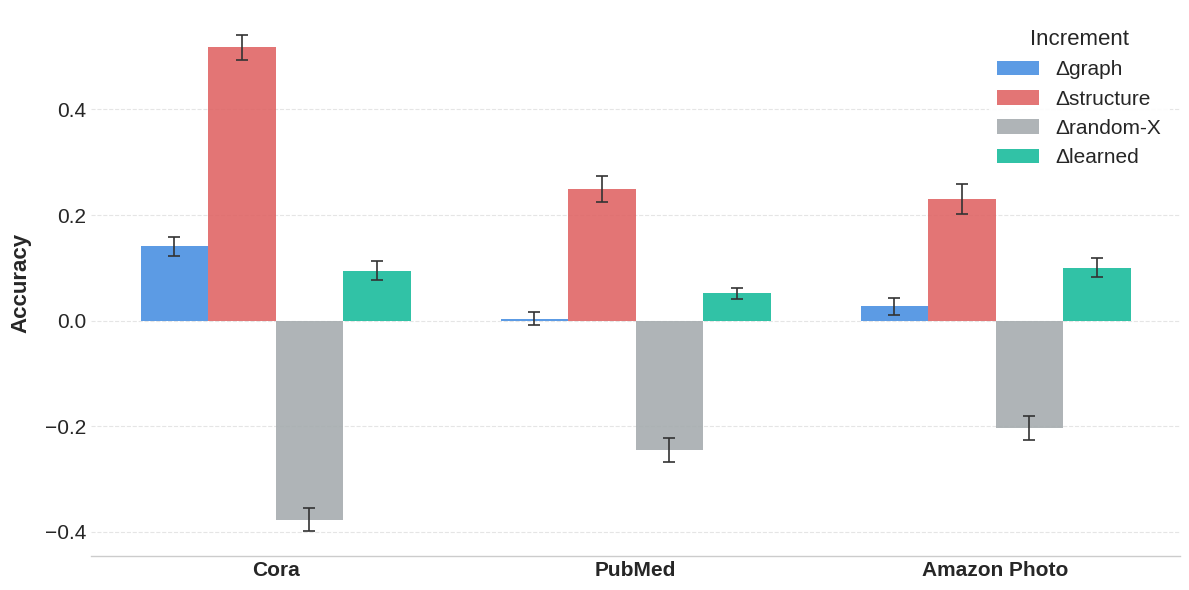

In [193]:
# 1. Set a clean, professional base style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

# 2. Define the consistent color palette & legend labels
EXTRA_COLORS = ['#4A90E2', '#E06666', '#A6ACAF', '#1ABC9C', '#748896', '#F39C12'] # Fallback for other models

LABEL_MAP = {
    'graph': 'Δgraph',
    'structure': 'Δstructure',
    'random_vs_x': 'Δrandom-X',
    'learned': 'Δlearned',
}

# 3. Gather datasets and identify all unique models across them dynamically
datasets = ['cora', 'pubmed', 'amazon']
all_types = []
for dataset in datasets:
    for type in mean_deltas[dataset].keys():
        if type not in all_types:
            all_types.append(type)

# Assign colors dynamically for any extra model types not explicitly mapped
extra_idx = 0
for type in all_types:
    if type not in COLOR_MAP:
        COLOR_MAP[type] = EXTRA_COLORS[extra_idx % len(EXTRA_COLORS)]
        extra_idx += 1

# 4. Set up the single figure and layout dimensions
fig, ax = plt.subplots(figsize=(12, 6))

num_datasets = len(datasets)
num_types = len(all_types)
total_group_width = 0.75  # Total width fraction allocated for each dataset's cluster of bars
bar_width = total_group_width / num_types
x_indices = np.arange(num_datasets)

# Subtle background grid (horizontal lines only)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.grid(False, axis='x') 

# 5. Plot grouped bars type by type across all datasets
for i, type in enumerate(all_types):
    # Fallback to 0 if a specific model doesn't exist in a dataset
    y = [mean_deltas[dataset].get(type, 0) for dataset in datasets]
    yerr = [std_deltas[dataset].get(type, 0) for dataset in datasets]
    
    # Calculate perfectly centered offsets for each bar within its dataset cluster
    offset = (i - (num_types - 1) / 2) * bar_width
    positions = x_indices + offset
    
    ax.bar(positions, y, width=bar_width, 
           label=LABEL_MAP.get(type, type.replace('_', ' ').title()), 
           color=COLOR_MAP[type], alpha=0.9,
           yerr=yerr, capsize=4, 
           error_kw={'ecolor': '#333333', 'elinewidth': 1.2, 'capthick': 1.2},
           zorder=3)

# 6. Clean up axes, titles, & labels
ax.set_xticks(x_indices)
display_names = [idx_to_name.get(ds, ds) for ds in datasets]
ax.set_xticklabels(display_names, fontsize=15, fontweight='semibold')
# ax.set_xlabel('Dataset', fontsize=16, labelpad=10, fontweight='semibold')

ax.set_ylabel('Accuracy', fontsize=16, labelpad=10, fontweight='semibold')
ax.tick_params(axis='y', labelsize=15)

# Title styling
# ax.set_title('Model Performance Comparison Across Datasets', fontsize=17, pad=20, fontweight='bold', color='#333333')

# Remove unnecessary border spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Clean, floating legend panel
ax.legend(title='Increment', title_fontsize=16, loc='upper right', frameon=True, facecolor='white', edgecolor='none', framealpha=0.9, fontsize=15)

# Dynamically give the highest bar a bit of top breathing room for the legend
all_y_values = [val for dataset_dict in mean_deltas.values() for val in dataset_dict.values()]
# if all_y_values:
#     ax.set_ylim(0, max(all_y_values) * 1.2)

plt.tight_layout()
plt.savefig("figures/delta_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [194]:
mean_times = {}

for dataset in ['cora', 'pubmed', 'amazon']:
    mean_times[dataset] = {
        'mlp_x': 0,
        'faf_true': 0,
        'faf_rand': 0,
        'gcn': 0,
    }

for seed, datasets in final_data.items():
    for dataset, models in datasets.items():
        for model, stats in models.items():
            if model == 'deltas':
                continue
            mean_times[dataset][model] += stats['time']

for dataset, models in mean_times.items():
    for model in models:
        mean_times[dataset][model] /= len(final_data)

In [195]:
std_times = {}

for dataset in ['cora', 'pubmed', 'amazon']:
    std_times[dataset] = {
        'mlp_x': 0,
        'faf_true': 0,
        'faf_rand': 0,
        'gcn': 0,
    }

for seed, datasets in final_data.items():
    for dataset, models in datasets.items():
        for model, stats in models.items():
            if model == 'deltas':
                continue
            std_times[dataset][model] += (stats['time'] - mean_times[dataset][model]) ** 2

for dataset, models in std_times.items():
    for model in models:
        std_times[dataset][model] = (std_times[dataset][model] / len(final_data)) ** 0.5

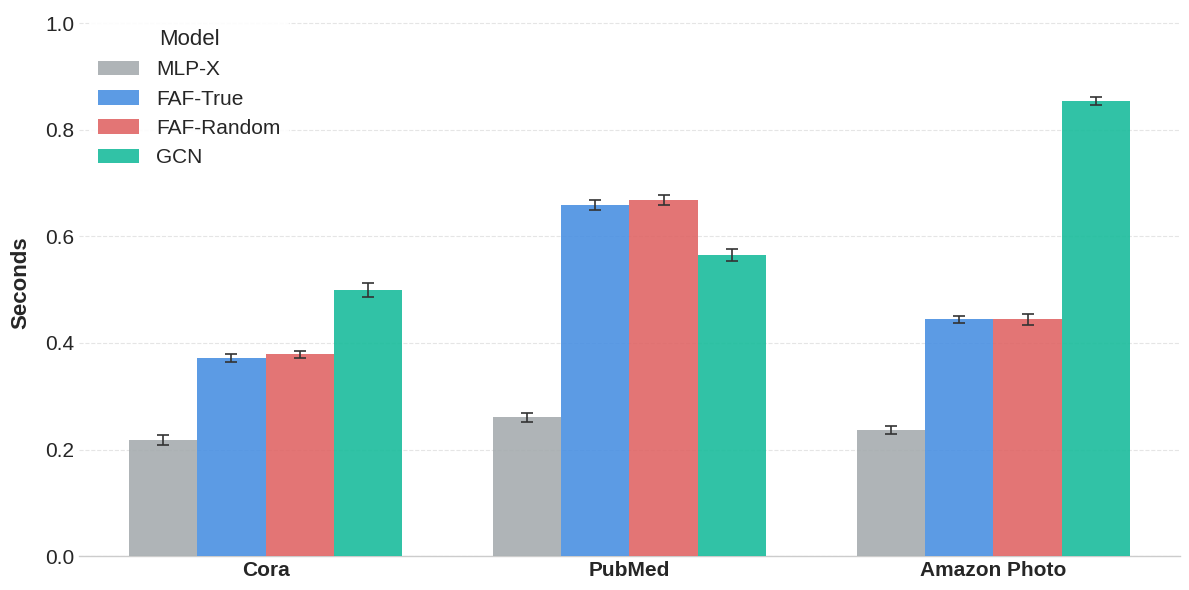

In [196]:
# 1. Set a clean, professional base style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

# 2. Define the consistent color palette & legend labels
COLOR_TRUE = '#4A90E2'   # Sleek Slate Blue
COLOR_RAND = '#E06666'   # Soft Coral
EXTRA_COLORS = ['#A6ACAF', '#1ABC9C', '#748896', '#F39C12'] # Fallback for other models

COLOR_MAP = {
    'faf_true': COLOR_TRUE,
    'faf_rand': COLOR_RAND
}

LABEL_MAP = {
    'mlp_x': 'MLP-X',
    'faf_true': 'FAF-True',
    'faf_rand': 'FAF-Random',
    'gcn': 'GCN',
}

# 3. Gather datasets and identify all unique models across them dynamically
datasets = ['cora', 'pubmed', 'amazon']
all_models = []
for dataset in datasets:
    for model in mean_times[dataset].keys():
        if model not in all_models:
            all_models.append(model)

# Assign colors dynamically for any extra model types not explicitly mapped
extra_idx = 0
for model in all_models:
    if model not in COLOR_MAP:
        COLOR_MAP[model] = EXTRA_COLORS[extra_idx % len(EXTRA_COLORS)]
        extra_idx += 1

# 4. Set up the single figure and layout dimensions
fig, ax = plt.subplots(figsize=(12, 6))

num_datasets = len(datasets)
num_models = len(all_models)
total_group_width = 0.75  # Total width fraction allocated for each dataset's cluster of bars
bar_width = total_group_width / num_models
x_indices = np.arange(num_datasets)

# Subtle background grid (horizontal lines only)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.grid(False, axis='x') 

# 5. Plot grouped bars model by model across all datasets
for i, model in enumerate(all_models):
    # Fallback to 0 if a specific model doesn't exist in a dataset
    y = [mean_times[dataset].get(model, 0) for dataset in datasets]
    yerr = [std_times[dataset].get(model, 0) for dataset in datasets]
    
    # Calculate perfectly centered offsets for each bar within its dataset cluster
    offset = (i - (num_models - 1) / 2) * bar_width
    positions = x_indices + offset
    
    ax.bar(positions, y, width=bar_width, 
           label=LABEL_MAP.get(model, model.replace('_', ' ').title()), 
           color=COLOR_MAP[model], alpha=0.9,
           yerr=yerr, capsize=4, 
           error_kw={'ecolor': '#333333', 'elinewidth': 1.2, 'capthick': 1.2},
           zorder=3)

# 6. Clean up axes, titles, & labels
ax.set_xticks(x_indices)
display_names = [idx_to_name.get(ds, ds) for ds in datasets]
ax.set_xticklabels(display_names, fontsize=15, fontweight='semibold')
# ax.set_xlabel('Dataset', fontsize=16, labelpad=10, fontweight='semibold')

ax.set_ylabel('Seconds', fontsize=16, labelpad=10, fontweight='semibold')
ax.tick_params(axis='y', labelsize=15)

# Title styling
# ax.set_title('Model Performance Comparison Across Datasets', fontsize=17, pad=20, fontweight='bold', color='#333333')

# Remove unnecessary border spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Clean, floating legend panel
ax.legend(title='Model', title_fontsize=16, loc='upper left', frameon=True, facecolor='white', edgecolor='none', framealpha=0.9, fontsize=15)

# Dynamically give the highest bar a bit of top breathing room for the legend
all_y_values = [val for dataset_dict in mean_times.values() for val in dataset_dict.values()]
if all_y_values:
    ax.set_ylim(0, max(all_y_values) * 1.2)

plt.tight_layout()
plt.savefig("figures/time_plot.png", dpi=300, bbox_inches="tight")
plt.show()